# GeoClip Zero-Shot Baseline

Evaluate pretrained GeoClip on the MMlandmarks query set **without fine-tuning**.
The model embeds query ground images and gallery GPS coordinates into a shared
512-dim space, then retrieves the nearest GPS by cosine similarity.

**Gallery:** configurable via `gallery.source` in [configs/geoclip_baseline.yaml](../../configs/geoclip_baseline.yaml):
- `"paper"` (default, 100,539 coords = 99,539 index-satellite + 1,000 query-landmark GPS) — matches the camera-ready MML paper Sec 5.2 protocol. Reproduces the 21.37 % @1 km row of Table 3. Because every query's GT GPS is in the gallery, this is an **upper bound**.
- `"index"` (99,539 coords) — index-satellite only. Honest in-the-wild result (~6.67 % @1 km). Per the paper author: *"21 % is a geolocalization upper limit, 6.67 % is more realistic in the wild."*

**Queries:** 18,688 query ground images (multiple images per landmark, each scored against the landmark's ground-truth GPS).

**Metric:** Accuracy @ {1, 25, 200, 750, 2500} km (Haversine distance).

## 1. Setup

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

plt.rcParams.update({"figure.dpi": 120})

# Load config
with open("../../configs/geoclip_baseline.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_ROOT = Path("../../") / cfg["data"]["root"]
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

device = cfg["inference"]["device"] if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Data root: {DATA_ROOT.resolve()}")

Device: cuda
Data root: /dtu/blackhole/02/137570/MML


## 2. Load Model

In [2]:
from mmgeo.geolocalizations.geoclip.geoclip_baseline import (
    GeoClipBaseline,
    load_gallery_coords,
    load_query_data,
)
from mmgeo.geolocalizations.geoclip.evaluate import (
    accuracy_at_thresholds,
    median_error,
    haversine,
)

baseline = GeoClipBaseline(device=device)

total_params = sum(p.numel() for p in baseline.model.parameters())
trainable_params = sum(p.numel() for p in baseline.model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Loading weights:   4%|▍         | 24/590 [00:00<00:02, 204.96it/s]

Loading weights:   8%|▊         | 45/590 [00:00<00:07, 71.43it/s] 

Loading weights:  10%|▉         | 57/590 [00:00<00:07, 71.03it/s]

...

Loading weights: 100%|██████████| 590/590 [00:05<00:00, 101.86it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/location_encoder.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sel

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/GeoCLIP.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.image_e

Total parameters: 438,050,306
Trainable parameters: 10,432,257


## 3. Build GPS Gallery

In [3]:
# Load both galleries up-front; we rebuild per-source before each inference pass.
GALLERY_SOURCES = ["paper", "index"]
galleries = {}
for source in GALLERY_SOURCES:
    coords = load_gallery_coords(DATA_ROOT, source=source)
    galleries[source] = coords
    print(
        f"source={source!r:>8}: {len(coords):>6,} GPS points · "
        f"lat [{coords[:, 0].min():.2f}, {coords[:, 0].max():.2f}] · "
        f"lon [{coords[:, 1].min():.2f}, {coords[:, 1].max():.2f}]"
    )


source= 'paper': 100,539 GPS points · lat [20.00, 49.03] · lon [-155.89, -66.93]


source= 'index': 99,539 GPS points · lat [20.00, 49.03] · lon [-155.89, -66.93]


## 4. Load Query Data

In [4]:
image_paths, true_coords, landmark_ids = load_query_data(DATA_ROOT)
print(f"Query landmarks: {len(image_paths)}")
print(image_paths[0])



# Verify all image files exist
missing = [p for p in image_paths if not p.exists()]
if missing:
    print(f"WARNING: {len(missing)} images not found. First missing: {missing[0]}")
else:
    print("All query images found.")

Query landmarks: 18688
../../data/MML_Data/query/ground/9/b/9/9b9ee86db9dfe4f5.jpg


All query images found.


## 5. Run Inference

In [5]:
# Run inference once per gallery source. Model weights stay the same; only the
# gallery (GPS embeddings cached inside baseline) changes between runs.
predictions = {}
for source, coords in galleries.items():
    print(f"\n[{source}] build_gallery ({len(coords):,} GPS points)…")
    baseline.build_gallery(coords)
    t0 = time.time()
    predictions[source] = baseline.predict_batch(
        image_paths, batch_size=cfg["inference"]["batch_size"]
    )
    print(f"[{source}] {len(predictions[source])} predictions in {time.time() - t0:.1f}s")



[paper] build_gallery (100,539 GPS points)…


Predicting:   0%|          | 0/292 [00:00<?, ?batch/s]

Predicting:   0%|          | 1/292 [00:23<1:56:21, 23.99s/batch]

Predicting:   1%|          | 2/292 [00:26<53:36, 11.09s/batch]  

Predicting:   1%|          | 3/292 [00:27<33:00,  6.85s/batch]

...

Predicting:  99%|█████████▉| 290/292 [08:54<00:03,  1.85s/batch]

Predicting: 100%|█████████▉| 291/292 [08:56<00:01,  1.84s/batch]

Predicting: 100%|██████████| 292/292 [08:58<00:00,  1.84s/batch]

Predicting: 100%|██████████| 292/292 [08:58<00:00,  1.84s/batch]

[index] 18688 predictions in 538.3s


## 6. Evaluate

In [6]:
thresholds = cfg["evaluation"]["thresholds_km"]
true_lat, true_lon = true_coords[:, 0], true_coords[:, 1]

results_by_source = {}
distances_by_source = {}
for source, preds in predictions.items():
    p_lat, p_lon = preds[:, 0], preds[:, 1]
    results_by_source[source] = accuracy_at_thresholds(
        p_lat, p_lon, true_lat, true_lon, thresholds
    )
    distances_by_source[source] = haversine(p_lat, p_lon, true_lat, true_lon)

# Side-by-side comparison table: rows = thresholds, columns = sources.
rows = []
for t in thresholds:
    row = {"Threshold (km)": t}
    for source in GALLERY_SOURCES:
        row[f"{source} (%)"] = f"{results_by_source[source][t] * 100:.2f}"
    rows.append(row)
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

print()
for source in GALLERY_SOURCES:
    d = distances_by_source[source]
    print(f"{source:>6}: median error {np.median(d):.1f} km · mean {d.mean():.1f} km")


 Threshold (km) paper (%) index (%)
              1     21.35      6.67
             25     36.44     28.79
            200     48.61     44.48
            750     71.41     69.07
           2500     91.52     91.07

 paper: median error 225.2 km · mean 674.6 km
 index: median error 294.3 km · mean 724.2 km


## 7. Visualizations

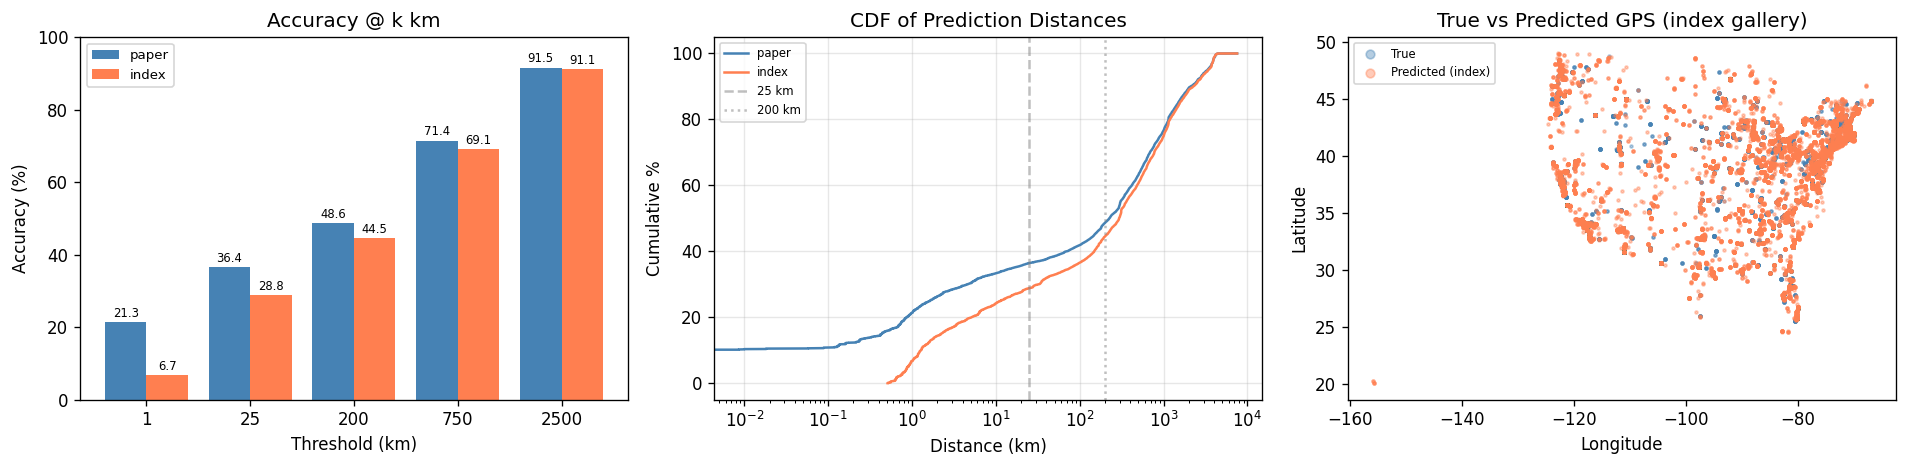

In [7]:
colors = {"paper": "steelblue", "index": "coral"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) grouped bar chart: accuracy @ k km per source
ax = axes[0]
x = np.arange(len(thresholds))
width = 0.4
for i, source in enumerate(GALLERY_SOURCES):
    vals = [results_by_source[source][t] * 100 for t in thresholds]
    offset = (i - (len(GALLERY_SOURCES) - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=source, color=colors[source])
    for xi, v in zip(x + offset, vals):
        ax.text(xi, v + 1.5, f"{v:.1f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("Threshold (km)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy @ k km")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)

# (b) CDF of prediction distances — one line per source
ax = axes[1]
for source in GALLERY_SOURCES:
    d = np.sort(distances_by_source[source])
    cdf = np.arange(1, len(d) + 1) / len(d)
    ax.plot(d, cdf * 100, linewidth=1.5, color=colors[source], label=source)
ax.set_xscale("log")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Cumulative %")
ax.set_title("CDF of Prediction Distances")
ax.axvline(25, color="gray", linestyle="--", alpha=0.5, label="25 km")
ax.axvline(200, color="gray", linestyle=":", alpha=0.5, label="200 km")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) Scatter: true vs predicted GPS — use the 'index' predictions (realistic spread;
# 'paper' predictions would overlap true exactly because query GT is in the gallery).
ax = axes[2]
preds = predictions["index"]
ax.scatter(true_coords[:, 1], true_coords[:, 0], s=3, alpha=0.4, label="True", color="steelblue")
ax.scatter(preds[:, 1], preds[:, 0], s=3, alpha=0.4, label="Predicted (index)", color="coral")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("True vs Predicted GPS (index gallery)")
ax.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()


## 8. Summary for Zero Shot

Zero-shot GeoClip on MMlandmarks, 18,688 query ground images, V100. Single HPC submit
runs both gallery sources back-to-back.

### `gallery.source: paper` — paper protocol (index + query = 100,539 GPS)

Reproduces the MML paper's Table 3 off-the-shelf GeoCLIP row within rounding. Because
every query's GT GPS sits in the gallery, this is an **upper bound** on achievable
performance, not an in-the-wild number.

| Threshold (km) | Accuracy (%) |
|---------------:|-------------:|
| 1              | 21.35        |
| 25             | 36.44        |
| 200            | 48.61        |
| 750            | 71.41        |
| 2500           | 91.52        |

- **Median error:** 225.2 km
- **Mean error:** 674.6 km

### `gallery.source: index` — honest in-the-wild (99,539 GPS, no query leakage)

Same model, query GT GPS removed from the gallery. Measures what off-the-shelf GeoCLIP
can actually do on US landmark localization without gallery leakage. Per Oskar
Kristoffersen (first author): *"21 % is a geolocalization upper limit, 6.67 % is more
realistic in the wild."*

| Threshold (km) | Accuracy (%) |
|---------------:|-------------:|
| 1              |  6.67        |
| 25             | 28.79        |
| 200            | 44.48        |
| 750            | 69.07        |
| 2500           | 91.07        |

- **Median error:** 294.3 km
- **Mean error:** 724.2 km

### Paper contrast

| Method | Dataset | Gallery | @1 km | @25 km | @200 km | @750 km | @2500 km |
|---|---|---:|---:|---:|---:|---:|---:|
| GeoClip (own paper) | Im2GPS3k (global) | 100k | 14.11 | 34.47 | 50.65 | 69.67 | 83.82 |
| Off-shelf GeoClip (MML paper) | MMlandmarks (US) | 101k (index+query) | **21.37** | **36.44** | 48.57 | 71.45 | 91.50 |
| **Ours (`paper`)** | MMlandmarks (US) | 101k (index+query) | **21.35** | **36.44** | 48.61 | 71.41 | 91.52 |
| **Ours (`index`)** | MMlandmarks (US) | 100k (index only) | **6.67** | **28.79** | 44.48 | 69.07 | 91.07 |

We reproduce the MML paper row to within 0.02 points at @1 km. The gap between the two
`Ours` rows is the query-leakage effect: including query GT coordinates in the gallery
gives the model a guaranteed-correct candidate to pick, inflating all thresholds.

> An earlier run on the 17,557 train-landmark gallery scored 19.22 % @1 km. That number
> is inflated by cluster-luck — train and query landmarks co-locate in the same tourist
> cities, so the nearest train-landmark GPS is often coincidentally <1 km from a query.
> Not a fair comparison to either of the paper galleries above.

**Next steps (Phase 2):** Fine-tune the Location Encoder and linear image head on the
MMlandmarks train split. Fair improvement lives on top of the `index` baseline
(28.79 % @25 km, not 36.44 %) — the paper gallery's leakage makes it hard to beat by
model changes alone.